In [13]:
import math
import os
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

In [14]:
data_root = 'data'
user_numbers = ['1']  # matches recorder -u / --user-number
user_colors = ['red', 'blue', 'green']
task_performed_values = ['roll', 'pitch', 'yaw']  # matches recorder -t / --task-performed
diameter_mm = 50  # matches recorder -s / --diameter-mm
trial_numbers = ['1', '2', '3', '4', '5']  # matches recorder -tn / --trial-number
line_styles = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3,1,1,1,1,1))]
marker_styles = ['o', 's', 'D', '^', 'v']
data_dir_dict = {}
pca_dict = {}
pca_components_keys = ['components', 'variance', 'variance_ratio']
pca_features = [
    'Thumb Fx', 'Index Fx', 'Middle Fx',
    'Thumb Fy', 'Index Fy', 'Middle Fy',
    'Thumb Fz', 'Index Fz', 'Middle Fz',
]
pca_order = [0, 3, 6, 1, 4, 7, 2, 5, 8]
pca_dim = len(pca_features)


def get_trial_dir(data_root, user_number, diameter_mm, task_performed, trial_number):
    return os.path.join(
        data_root,
        f'user_{user_number}',
        f'{diameter_mm}mm',
        task_performed,
        f'trial_{trial_number}',
    )


for task_performed in task_performed_values:
    data_dir_dict[task_performed] = {}
    pca_dict[task_performed] = {}
    for user_number in user_numbers:
        data_dir_dict[task_performed][user_number] = [
            get_trial_dir(data_root, user_number, diameter_mm, task_performed, trial_number)
            for trial_number in trial_numbers
        ]
        pca_dict[task_performed][user_number] = {}
        for pca_comp in pca_components_keys:
            pca_dict[task_performed][user_number][pca_comp] = []

# Function Libs

In [15]:
def quick_visualization(data):

    max_val = np.max(data)
    min_val = np.min(data)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(311)
    ax1.plot(data[:, 0])
    ax1.plot(data[:, 1])
    ax1.plot(data[:, 2])
    ax1.set_title(f'Force Data - Thumb')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Force (N)')
    ax1.legend(['Fx', 'Fy', 'Fz'])
    ax1.set_ylim(low_bound, up_bound)

    ax2 = fig.add_subplot(312)
    ax2.plot(data[:, 3])
    ax2.plot(data[:, 4])
    ax2.plot(data[:, 5])
    ax2.set_title(f'Force Data - Index')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Force (N)')
    ax2.legend(['Fx', 'Fy', 'Fz'])
    ax2.set_ylim(low_bound, up_bound)

    ax3 = fig.add_subplot(313)
    ax3.plot(data[:, 6])
    ax3.plot(data[:, 7])
    ax3.plot(data[:, 8])
    ax3.set_title(f'Force Data - Middle')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Force (N)')
    ax3.legend(['Fx', 'Fy', 'Fz'])
    ax3.set_ylim(low_bound, up_bound)
    
    plt.tight_layout()
    plt.show()

In [16]:
def load_single_trial(data_dir):
    thumb_path = os.path.join(data_dir, 'thumb.csv')
    index_path = os.path.join(data_dir, 'index.csv')
    middle_path = os.path.join(data_dir, 'middle.csv')

    missing_files = [
        path for path in [thumb_path, index_path, middle_path]
        if not os.path.exists(path)
    ]
    if missing_files:
        raise FileNotFoundError(
            'Missing recorder CSV file(s): ' + ', '.join(missing_files)
        )

    thumb = pd.read_csv(thumb_path)
    index = pd.read_csv(index_path)
    middle = pd.read_csv(middle_path)

    n_samples = min(len(thumb), len(index), len(middle))
    if n_samples == 0:
        raise ValueError(
            f'One or more finger CSVs are empty in {data_dir}. '
            f'Rows: thumb={len(thumb)}, index={len(index)}, middle={len(middle)}'
        )

    return np.column_stack([
        thumb[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
        index[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
        middle[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
    ])


def load_data(data_dir_lis, visualize=False):
    data_lis_arr = []
    for data_dir in data_dir_lis:
        data = load_single_trial(data_dir)
        if visualize:
            quick_visualization(data)
        data_lis_arr.append(data)
    
    return data_lis_arr

In [17]:
def pca_analysis(data, n_components=pca_dim):
    pca = PCA(n_components=n_components)
    pca.fit_transform(data)
    return pca.components_, pca.explained_variance_, pca.explained_variance_ratio_

In [18]:
def data_process(data_dir_dict, pca_dict, visualize_flag=False):
    for task_performed in task_performed_values:
        for user_number in user_numbers:
            data_lis = data_dir_dict[task_performed][user_number]
            data_lis_arr = load_data(data_lis, visualize=visualize_flag)
            for data in data_lis_arr:
                components, variance, variance_ratio = pca_analysis(data)
                pca_dict[task_performed][user_number]['components'].append(components)
                pca_dict[task_performed][user_number]['variance'].append(variance)
                pca_dict[task_performed][user_number]['variance_ratio'].append(variance_ratio)
    return

In [19]:
def pca_data_analysis(pca_dict):
    for task_performed in task_performed_values:
        for user_number in user_numbers:
            print(f'User: {str(user_number)}, Task: {task_performed.capitalize()}')
            ratio_dict = {}
            for i in range(pca_dim):
                ratio_dict[i] = []

            for i in range(pca_dim):
                for j in range(len(trial_numbers)):
                    ratio = pca_dict[task_performed][user_number]['variance_ratio'][j][i]
                    ratio_dict[i].append(ratio)

            for i in range(pca_dim):
                mean_ratio = np.mean(ratio_dict[i])
                std_ratio = np.std(ratio_dict[i])
                print(f'PC{i+1}: {mean_ratio:.2%} ± {std_ratio:.2%}')

    return

In [20]:
def data_plotting(pca_dict):
    for task_performed in task_performed_values:
        figure, axes = plt.subplots(pca_dim, 1, figsize=(12, 3 * pca_dim))
        for ax in axes:
            ax.set_ylim(-1, 1)
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
        for z,user_number in enumerate(user_numbers):
            user_num = z + 1
            for i in range(len(trial_numbers)):
                components = pca_dict[task_performed][user_number]['components'][i]
                variance = pca_dict[task_performed][user_number]['variance'][i]
                variance_ratio = pca_dict[task_performed][user_number]['variance_ratio'][i]
                components_new = components[:, pca_order]
                # components_new = abs(components[:, pca_order])
                for j in range(components.shape[0]):
                    axes[j].plot(components_new[j], label=f'User {user_number}' if i==0 else None, color=user_colors[z], linestyle=line_styles[i])
                    axes[j].scatter(range(pca_dim), components_new[j], color=user_colors[z], marker=marker_styles[i], s=20, edgecolors='black', zorder=5)
                    axes[j].set_xticks(range(pca_dim))
                    axes[j].set_xticklabels(pca_features)
                    if z == len(user_numbers) - 1:
                        axes[j].set_ylabel(f'PC{j+1}')
                        if j == 0:
                            axes[j].set_title(f'{task_performed.capitalize()}')
                    axes[j].legend()
    return

In [21]:
def data_plotting2(pca_dict):
    for task_performed in task_performed_values:
        figure, axes = plt.subplots(pca_dim, 1, figsize=(12, 3 * pca_dim))

        # Ensure axes is always iterable
        if pca_dim == 1:
            axes = [axes]

        for ax in axes:
            ax.set_ylim(-1, 1)
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5)

        for z, user_number in enumerate(user_numbers):
            user_num = z + 1

            # collect all trials for this user
            all_trials = []

            for i in range(len(trial_numbers)):
                components = pca_dict[task_performed][user_number]['components'][i]

                # IMPORTANT: use copy so we can safely modify
                components_new = components[:, pca_order].copy()

                # 🔁 Flip sign so first value is consistent
                for j in range(components_new.shape[0]):
                    if components_new[j, 0] > 0:
                        components_new[j] = -components_new[j]

                all_trials.append(components_new)

            # convert to numpy array: (trials, pca_dim, features)
            all_trials = np.array(all_trials)

            # 📊 mean + std across trials
            mean_components = np.mean(all_trials, axis=0)
            std_components = np.std(all_trials, axis=0)

            x = range(len(pca_features))

            for j in range(mean_components.shape[0]):
                # mean line
                axes[j].plot(
                    x,
                    mean_components[j],
                    label=f'User {user_number}',
                    color=user_colors[z],
                    linewidth=2
                )

                # std shaded region
                axes[j].fill_between(
                    x,
                    mean_components[j] - std_components[j],
                    mean_components[j] + std_components[j],
                    color=user_colors[z],
                    alpha=0.2
                )

                # scatter points
                axes[j].scatter(
                    x,
                    mean_components[j],
                    color=user_colors[z],
                    s=30,
                    edgecolors='black',
                    zorder=5
                )

                axes[j].set_xticks(range(pca_dim))
                axes[j].set_xticklabels(pca_features)

                if z == len(user_numbers) - 1:
                    axes[j].set_ylabel(f'PC{j+1}')
                    if j == 0:
                        axes[j].set_title(f'{task_performed.capitalize()}')

                axes[j].legend()

        plt.tight_layout()
        plt.show()

    return

# Analysis

In [22]:
data_process(data_dir_dict, pca_dict, False)

/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Us

In [23]:
pca_data_analysis(pca_dict)

User: 1, Task: Roll
PC1: 55.50% ± 3.57%
PC2: 24.85% ± 2.64%
PC3: 9.42% ± 1.49%
PC4: 5.14% ± 0.69%
PC5: 2.58% ± 0.55%
PC6: 0.98% ± 0.17%
PC7: 0.76% ± 0.06%
PC8: 0.54% ± 0.10%
PC9: 0.23% ± 0.05%
User: 1, Task: Pitch
PC1: 64.77% ± 1.54%
PC2: 19.43% ± 1.31%
PC3: 6.21% ± 1.33%
PC4: 4.87% ± 0.53%
PC5: 1.84% ± 0.33%
PC6: 1.13% ± 0.11%
PC7: 0.76% ± 0.15%
PC8: 0.61% ± 0.09%
PC9: 0.39% ± 0.11%
User: 1, Task: Yaw
PC1: 57.85% ± 3.54%
PC2: 14.04% ± 1.01%
PC3: 10.75% ± 1.00%
PC4: 7.58% ± 1.02%
PC5: 3.29% ± 0.65%
PC6: 2.71% ± 0.72%
PC7: 1.81% ± 0.48%
PC8: 1.20% ± 0.28%
PC9: 0.77% ± 0.23%


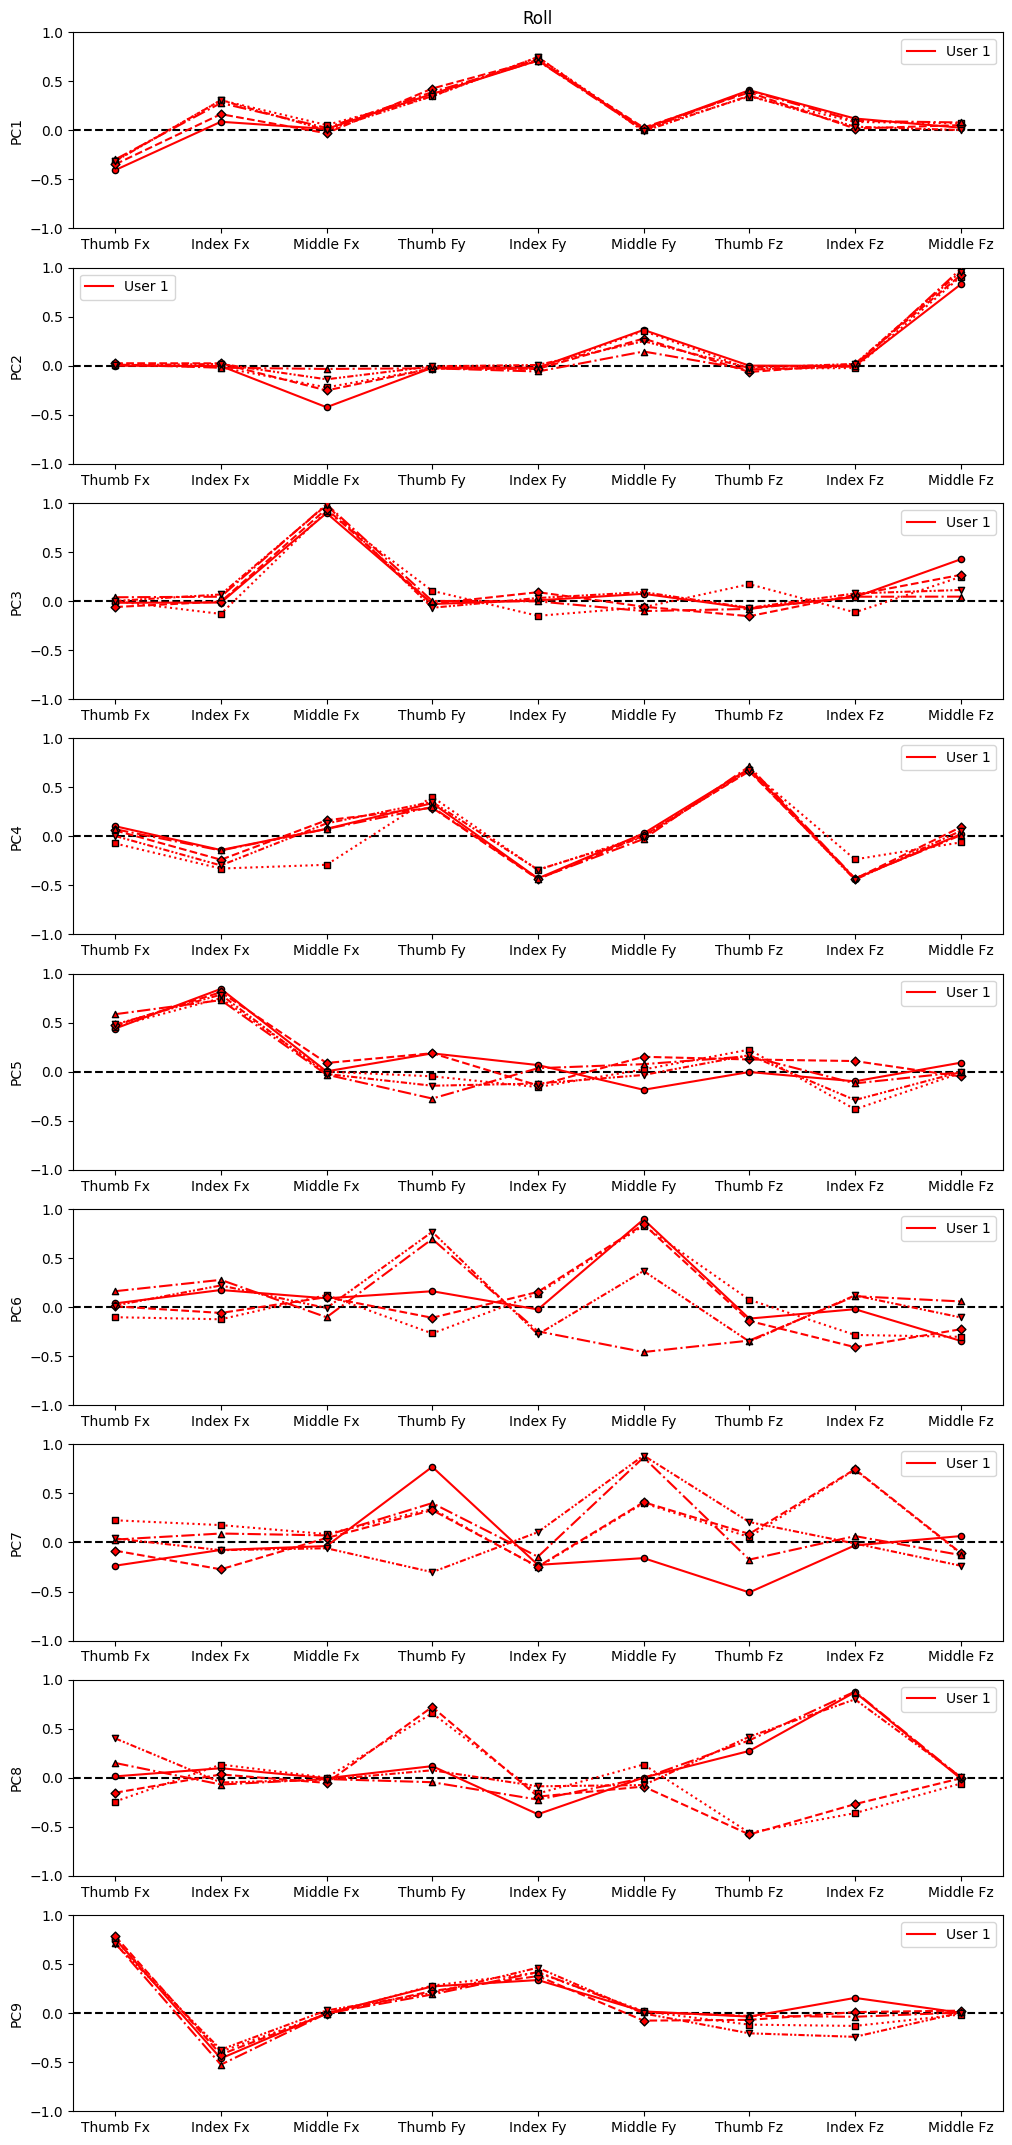

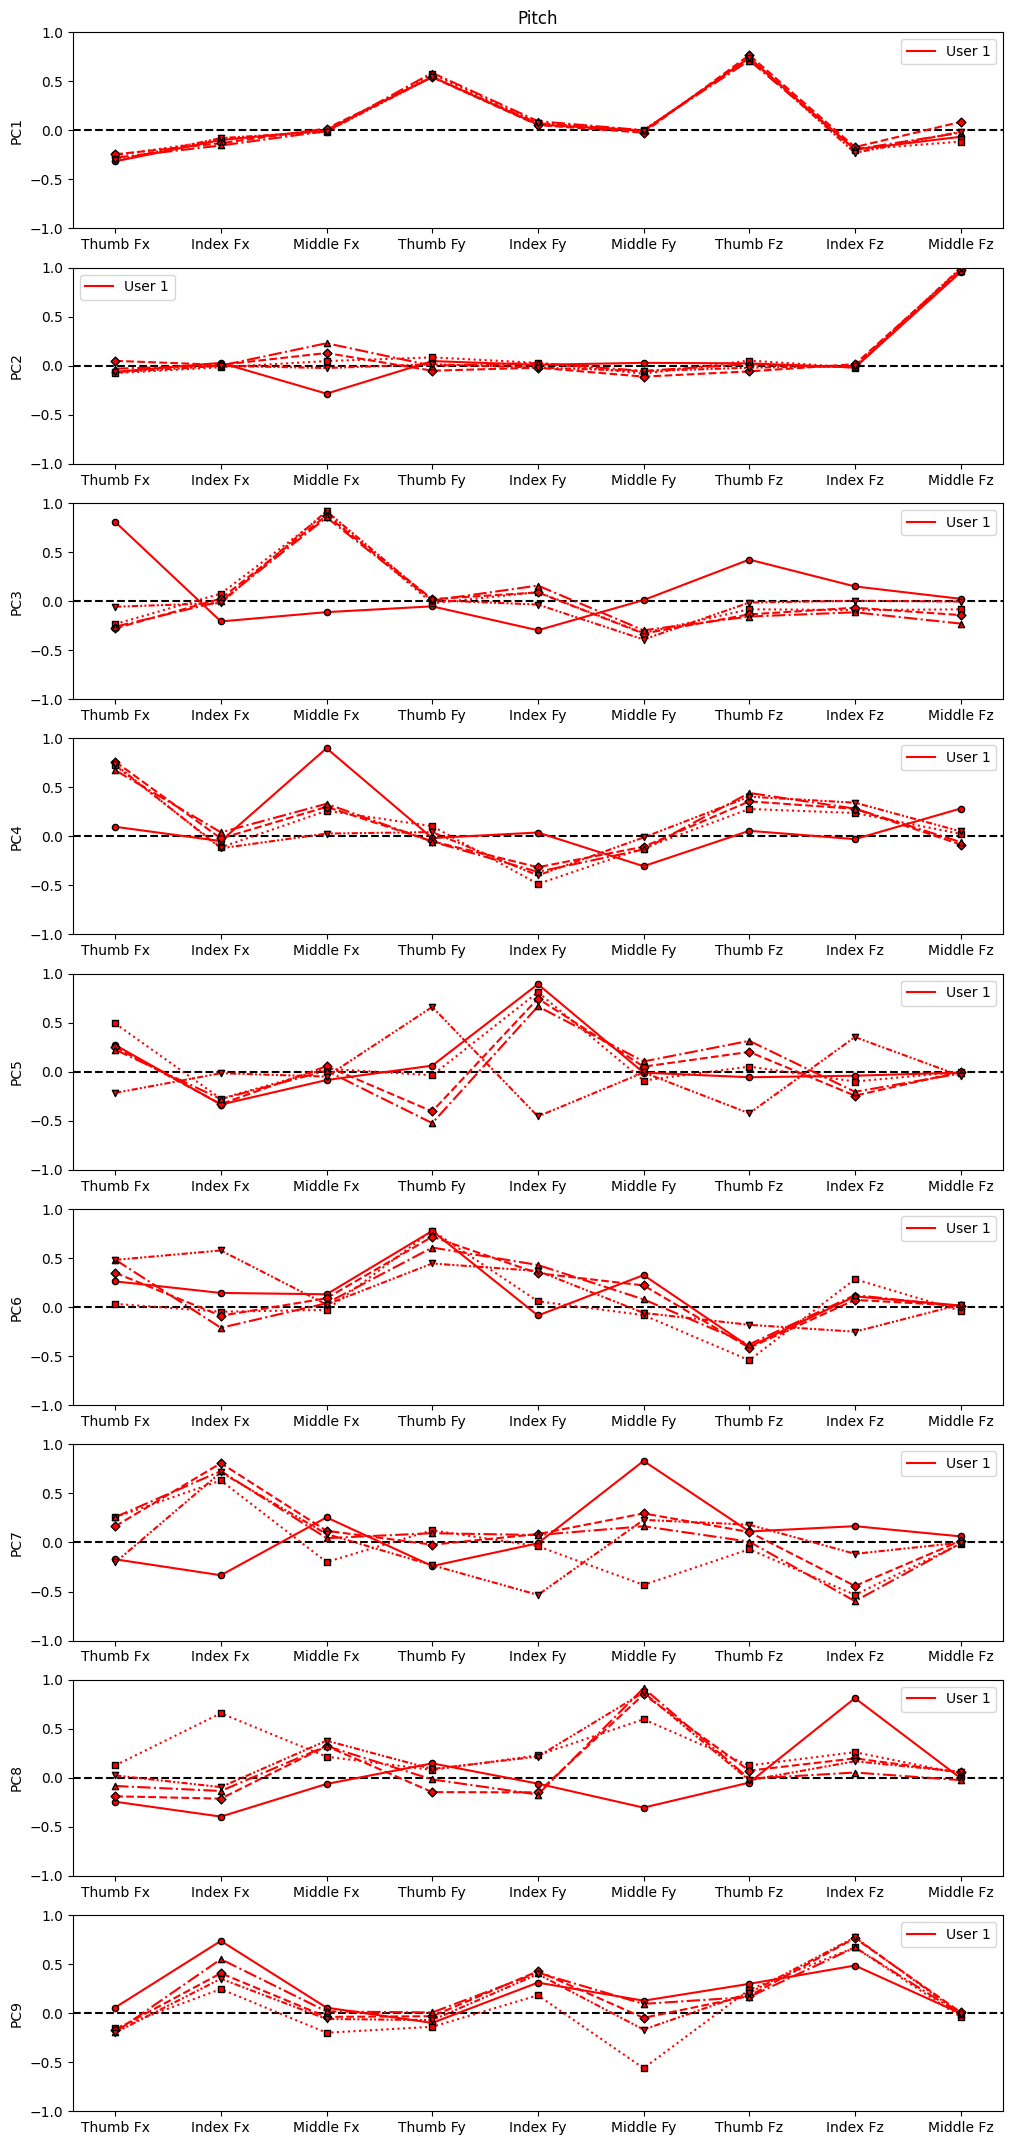

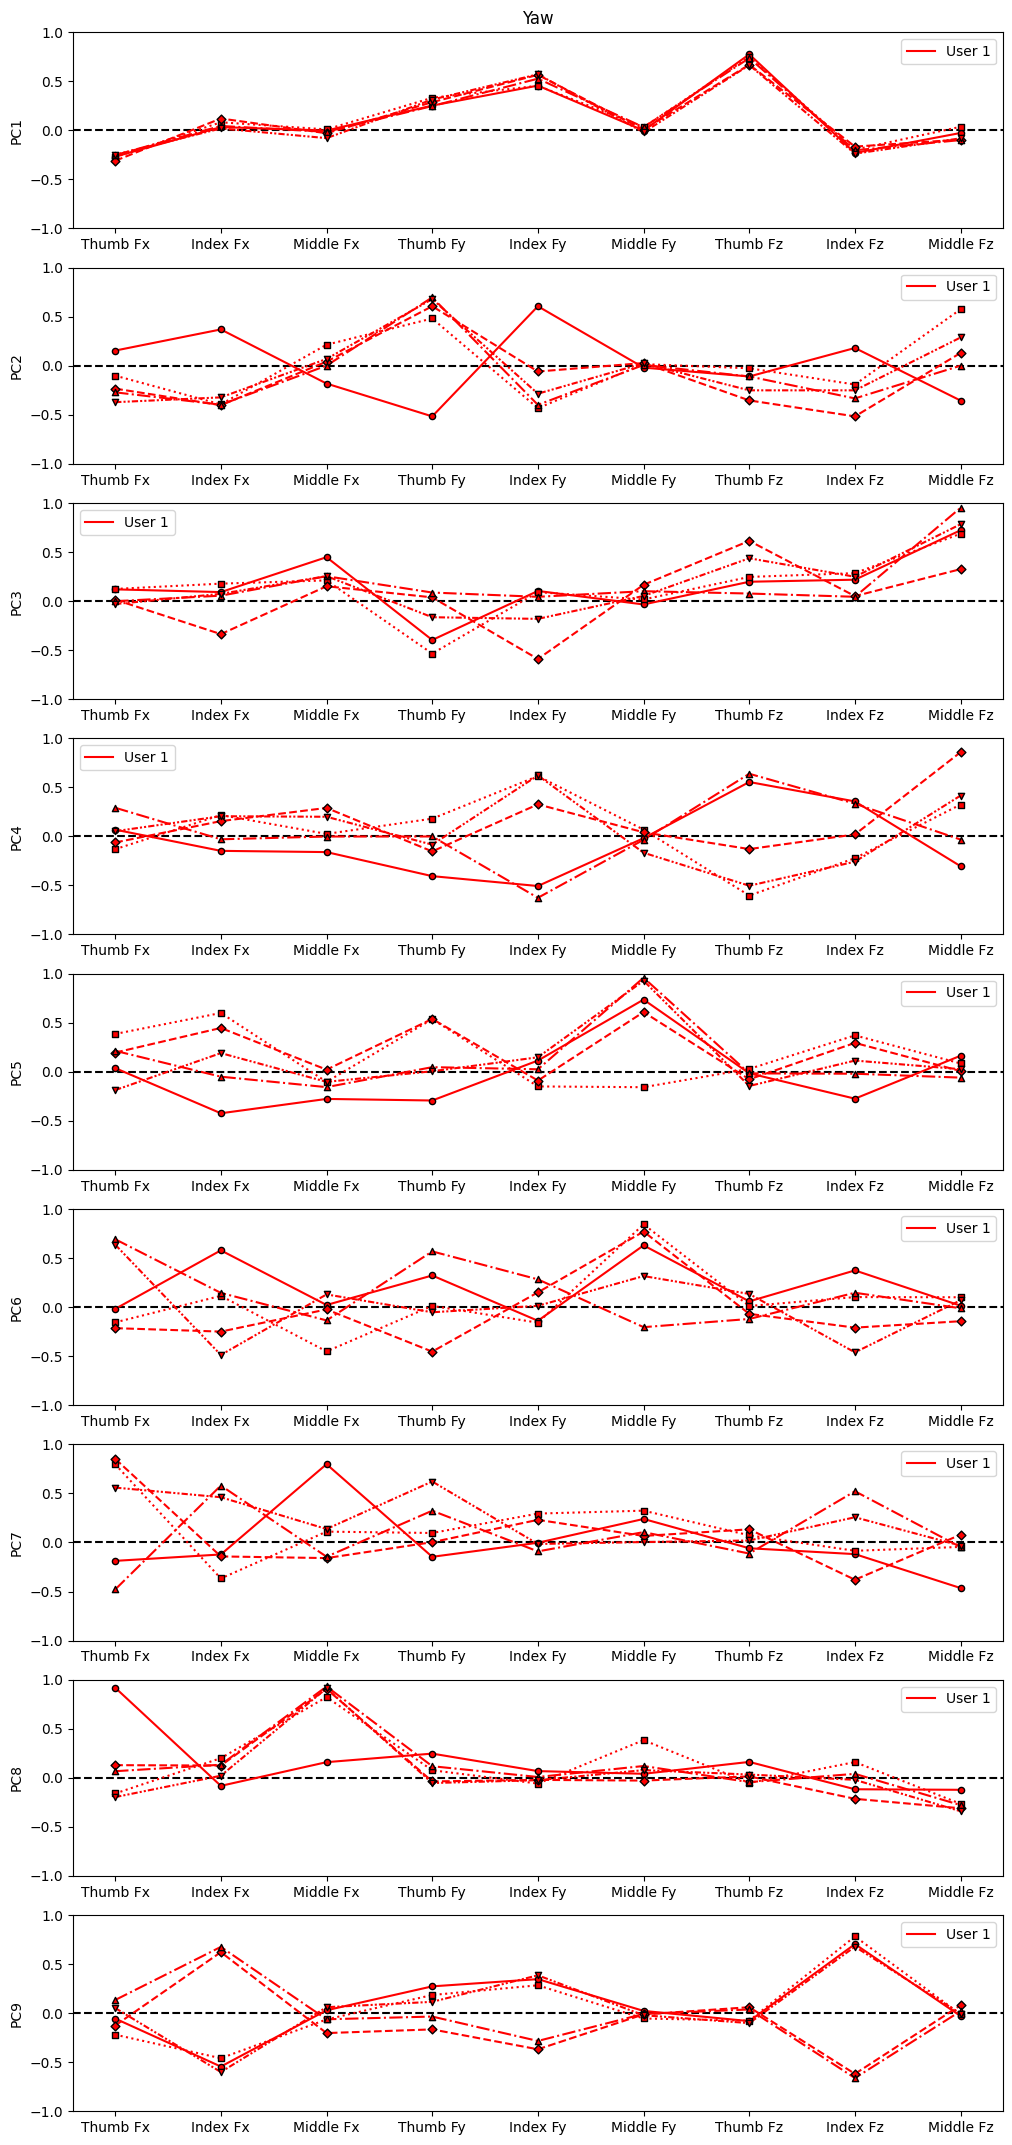

In [24]:
data_plotting(pca_dict)